# 04 - Initial LUX analysis

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns


import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import ambient_light_epilepsy.lux_metrics as lm
import time

In [4]:
def plot_group_scatter(df_control, df_pwe, column, ylabel):
    """
    Creates a two-group jittered scatter plot with group means.

    Parameters
    ----------
    df_control : DataFrame
    df_pwe : DataFrame
    column : str
        Column name to plot
    ylabel : str
        Label for y-axis
    """

    control_vals = df_control[column].dropna()
    pwe_vals = df_pwe[column].dropna()

    fig, ax = plt.subplots(figsize=(3, 3))

    # Jitter
    jitter_strength = 0.08
    x_control = np.random.normal(0, jitter_strength, size=len(control_vals))
    x_pwe = np.random.normal(1, jitter_strength, size=len(pwe_vals))

    ax.scatter(x_control, control_vals, alpha=0.6)
    ax.scatter(x_pwe, pwe_vals, alpha=0.6)

    # Plot group means
    ax.scatter(0, control_vals.mean(), s=150, marker="_")
    ax.scatter(1, pwe_vals.mean(), s=150, marker="_")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Controls", "PWE"])
    ax.set_ylabel(ylabel)
    ax.set_title(column)

    plt.tight_layout()
    plt.show()



def cohens_d_value(group1, group2):
    
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    
    sd1 = np.std(group1, ddof=1)
    sd2 = np.std(group2, ddof=1)
    
    n1 = len(group1)
    n2 = len(group2)
    
    # pooled SD
    sd_pooled = np.sqrt(
        ((n1 - 1)*sd1**2 + (n2 - 1)*sd2**2) / (n1 + n2 - 2)
    )
    
    return (mean1 - mean2) / sd_pooled




def add_employment_and_depression_status(df_all):
    # Load the OCD150 and employment status 
    ocq_G = nhn.load_employment("G")
    ocq_H = nhn.load_employment("H")
    
    # Load the depression status
    dpq_G = nhn.load_dpq("G")
    dpq_H = nhn.load_dpq("H")
    
    # Ensure SEQN types match (NHANES tables use float)
    df_all["SEQN"] = df_all["SEQN"].astype(float)
    
    # Extract only the columns we need
    ocq_G = ocq_G[["employed"]]
    ocq_H = ocq_H[["employed"]]
    
    dpq_G = dpq_G[["depressed"]]
    dpq_H = dpq_H[["depressed"]]
    
    # Split df_all by cohort
    df_G = df_all[df_all["cohort"] == "G"].copy()
    df_H = df_all[df_all["cohort"] == "H"].copy()
    
    # Merge employment
    df_G = df_G.merge(ocq_G, left_on="SEQN", right_index=True, how="left")
    df_H = df_H.merge(ocq_H, left_on="SEQN", right_index=True, how="left")
    
    # Merge depression
    df_G = df_G.merge(dpq_G, left_on="SEQN", right_index=True, how="left")
    df_H = df_H.merge(dpq_H, left_on="SEQN", right_index=True, how="left")
    
    # Combine cohorts back together
    df_all = pd.concat([df_G, df_H], ignore_index=True)

    return df_all


def add_demographic_data(df_all):
    
    # Load demographics
    demo_G = nhn.load_partial_demo("G")
    demo_H = nhn.load_partial_demo("H")

    demo_G = demo_G.drop("p_ed", axis=1)
    demo_H = demo_H.drop("p_ed", axis=1)
    
    # Ensure SEQN type matches (NHANES index is float)
    df_all["SEQN"] = df_all["SEQN"].astype(float)
    
    # Split df_all by cohort
    df_G = df_all[df_all["cohort"] == "G"].copy()
    df_H = df_all[df_all["cohort"] == "H"].copy()
    
    # Merge demographics
    df_G = df_G.merge(demo_G, left_on="SEQN", right_index=True, how="left")
    df_H = df_H.merge(demo_H, left_on="SEQN", right_index=True, how="left")
    
    # Combine back together
    df_all = pd.concat([df_G, df_H], ignore_index=True)

    # Rename 6_month to season 
    df_all = df_all.rename(columns={'6_month': 'season'})


    return df_all




def compute_lux_summary(seqn_array, year, base_path):
    """
    Computes:
        - mean lux across recording
        - recording length (hours)

    Returns DataFrame indexed by SEQN
    """

    results = []

    for seqn in seqn_array:
        file_path = Path(base_path) / f"PAXLUX_{year}" / "parquet_5min" / f"SEQN_{int(seqn)}_5min.parquet"

        if not file_path.exists():
            print(f"ERROR: path does not exist: {file_path}")
            continue

        try:
            pf = pq.ParquetFile(file_path)

            # Only read necessary columns
            table = pf.read(columns=["timestamp", "mean_lux"])
            df = table.to_pandas()

            if df.empty:
                print(f"ERROR: table is empty: {file_path}")
                continue


            # Create a daily LUX pattern by averaging over timepoints
            daily_pattern = df.groupby(df['timestamp'].dt.time)['mean_lux'].mean()

            # Determine the timezone for all data
            tz = df["timestamp"].dt.tz

            # Calculate the total duration of the recording in hours
            t_min = df["timestamp"].min()
            t_max = df["timestamp"].max()
            duration_hours = (t_max - t_min).total_seconds() / 3600

                            
            # Calculate mean light exposure (not actually useful, may remove)
            mean_lux = df["mean_lux"].mean()
            
            # Calculate mean daytime light exposure
            daytime_lux = lm.compute_mean_daytime_lux(df, day_start=7, day_end=19)
            
            # Calculate mean nightitme light exposure
            nighttime_lux = lm.compute_mean_nighttime_lux(df, night_start=20, night_end=5)

            # Calculate the time above threshold LUX level
            threshold = 1000
            mins, percent = lm.time_above_threshold_normalized(df, threshold=threshold)

            # Calculate m10, l5 and relative amplitude
            m10, l5, ra = lm.relative_amplitude(df)

            results.append({
                "timezone": tz,
                "SEQN": seqn,
                "duration_hours": duration_hours,
                "mean_lux": mean_lux,
                "mean_daytime_lux": daytime_lux,
                "mean_nighttime_lux": nighttime_lux,
                "time_above_threshold": mins,
                "M10": m10,
                "L5": l5, 
                "RA": ra,
                
            })

        except Exception as e:
            print(f"Error processing {seqn}: {e}")

    return pd.DataFrame(results).set_index("SEQN")


In [5]:
def plot_lux_distribution(df, x_col="epilepsy", y_col="mean_daytime_lux", use_log=True, ax=None, figsize=(5, 3)):
    """
    function to plot a violin plot to compare *y_col* over different *x_col* (epilepsy status) 
    """

    if ax == None:
        fig, ax = plt.subplots(figsize=figsize)
    
    # Optional: Transform data to log scale if specified, matches your OLS model
    plot_data = df.copy()
    if use_log:
        plot_data[y_col] = np.log1p(plot_data[y_col])
        ylabel = f"Log({y_col} + 1)"
    else:
        ylabel = y_col

    # Create the violin plot
    sns.violinplot(
        data=plot_data, 
        x=x_col, 
        y=y_col, 
        inner="box",      # Draws a mini boxplot inside the violin
        palette="muted", 
        hue=x_col,
        cut=0,             # Limits the violin to the actual data range
        ax=ax
    )
    
    plt.title(f"Daytime Lux Distribution by Group ({'Log Scale' if use_log else 'Linear'})")
    ax.set_xlabel("Group (0=Control, 1=Epilepsy)")
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)

    return ax

In [6]:
# base_path = "W:/projects/ambient_light_epilepsy_analysis/data"

# # Run analysis for G cohort 
# control_seqn, pwe_seqn = ch.load_freq_matched_control_groups("G")
# df_control_summary_G = compute_lux_summary(control_seqn, "G", base_path)
# df_pwe_summary_G     = compute_lux_summary(pwe_seqn, "G", base_path)

# # Run analysis for H cohort 
# control_seqn, pwe_seqn = ch.load_freq_matched_control_groups("H")
# df_control_summary_H = compute_lux_summary(control_seqn, "H", base_path)
# df_pwe_summary_H     = compute_lux_summary(pwe_seqn, "H", base_path)

# df_control_summary.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_{year}.csv")
# df_pwe_summary.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_{year}.csv")

In [7]:
# Load both summary tables for each cohort 
year = "G"
df_control_summary_G = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_G.csv")
df_pwe_summary_G = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_G.csv")

year = "H"
df_control_summary_H = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/control_lux_summary_H.csv")
df_pwe_summary_H = pd.read_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/pwe_lux_summary_H.csv")



# Add cohort and epilepsy labels before merging
def add_labels(df, cohort_label, epilepsy_status):
    df = df.copy()
    df["cohort"] = cohort_label
    df["epilepsy"] = epilepsy_status  # 1 = PWE, 0 = control
    return df
    
df_G_pwe = add_labels(df_pwe_summary_G, "G", 1)
df_G_ctrl = add_labels(df_control_summary_G, "G", 0)

df_H_pwe = add_labels(df_pwe_summary_H, "H", 1)
df_H_ctrl = add_labels(df_control_summary_H, "H", 0)

# Merge all 
df_all = pd.concat(
    [df_G_pwe, df_G_ctrl, df_H_pwe, df_H_ctrl],
    ignore_index=True
)

# Add employment and depression status to summary table 
df_all = add_employment_and_depression_status(df_all)

df_all = add_demographic_data(df_all)

# Save the analysis results as a CSV file
df_all.to_csv(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/analysis/lux_5min_fmatch_analysis.csv")

In [8]:
df_all

,SEQN,timezone,duration_hours,mean_lux,mean_daytime_lux,mean_nighttime_lux,time_above_threshold,M10,L5,RA,...,epilepsy,employed,depressed,age,sex,race,a_ed,PIR,NIH,season
0,62218.0,UTC,222.166667,133.016037,242.679336,19.242723,0.0,283.219554,2.546784,0.982176,...,1,0,0.0,38.0,2.0,4.0,4.0,4.05,3.0,1.0
1,62282.0,UTC,192.083333,20.843251,40.438316,0.953299,0.0,46.339642,0.003403,0.999853,...,1,1,0.0,57.0,2.0,4.0,5.0,1.70,2.0,1.0
2,62293.0,UTC,192.083333,18.989081,36.077126,1.818291,0.0,42.688042,1.205729,0.945061,...,1,0,NaN,67.0,1.0,3.0,4.0,1.16,1.0,2.0
3,62307.0,UTC,192.083333,44.976663,80.318809,4.919599,0.0,98.262948,1.641486,0.967139,...,1,0,0.0,61.0,1.0,4.0,3.0,1.20,2.0,2.0
4,62370.0,UTC,192.083333,62.269247,117.559670,1.761620,0.0,147.080298,0.000000,1.000000,...,1,0,0.0,21.0,1.0,6.0,4.0,3.70,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,81103.0,UTC,192.083333,122.073670,241.802721,0.923383,15.0,287.891632,0.397111,0.997245,...,0,0,0.0,80.0,1.0,4.0,3.0,2.67,2.0,1.0
857,81997.0,UTC,192.083333,184.755259,354.008004,10.198465,0.0,417.019819,0.200632,0.999038,...,0,0,0.0,80.0,1.0,3.0,4.0,1.02,4.0,1.0
858,78899.0,UTC,192.083333,49.309750,98.002270,0.595559,0.0,116.824593,0.000000,1.000000,...,0,0,0.0,80.0,1.0,3.0,5.0,2.78,3.0,1.0
859,76531.0,UTC,192.083333,20.822221,39.905744,1.034286,0.0,45.164121,0.245993,0.989166,...,0,0,0.0,80.0,1.0,3.0,1.0,1.91,4.0,1.0


In [9]:
def compare_distributions(df1, df2, label1="Controls", label2="PWE", column="mean_daytime_lux"):
    # Calculate describe for both and combine into one DataFrame
    comparison_df = pd.DataFrame({
        label1: df1[column].describe(),
        label2: df2[column].describe()
    })

    # Add median row 
    comparison_df.loc["median"] = [df1[column].median(), df2[column].median()]
    
    print(f"=== {column} Comparison ===")
    print(comparison_df)
    print()

# Define summary tables (combined beteen cohorts)
df_pwe_summary = df_all[df_all['epilepsy']==1]
df_control_summary = df_all[df_all['epilepsy']==0]

# Print descriptions of measuremnt distribtions
compare_distributions(df_control_summary, df_pwe_summary, column="mean_daytime_lux")
compare_distributions(df_control_summary, df_pwe_summary, column="mean_nighttime_lux")
compare_distributions(df_control_summary, df_pwe_summary, column="time_above_threshold")
compare_distributions(df_control_summary, df_pwe_summary, column="M10")
compare_distributions(df_control_summary, df_pwe_summary, column="L5")
compare_distributions(df_control_summary, df_pwe_summary, column="RA")

=== mean_daytime_lux Comparison ===
           Controls         PWE
count    669.000000  192.000000
mean     217.296609  170.323989
std      172.514337  135.147955
min        0.000000    1.306196
25%       92.706262   69.390610
50%      174.124809  135.007512
75%      300.149164  240.752253
max     1278.921097  682.232289
median   174.124809  135.007512

=== mean_nighttime_lux Comparison ===
          Controls         PWE
count   669.000000  192.000000
mean      7.572123    7.014556
std      13.605985   10.682189
min       0.000000    0.001578
25%       1.307785    1.102469
50%       3.801535    3.003198
75%       9.028927    8.334083
max     188.544248   70.069032
median    3.801535    3.003198

=== time_above_threshold Comparison ===
          Controls         PWE
count   669.000000  192.000000
mean     13.976084    7.239583
std      49.536378   23.355547
min       0.000000    0.000000
25%       0.000000    0.000000
50%       0.000000    0.000000
75%       5.000000    0.000000
max   

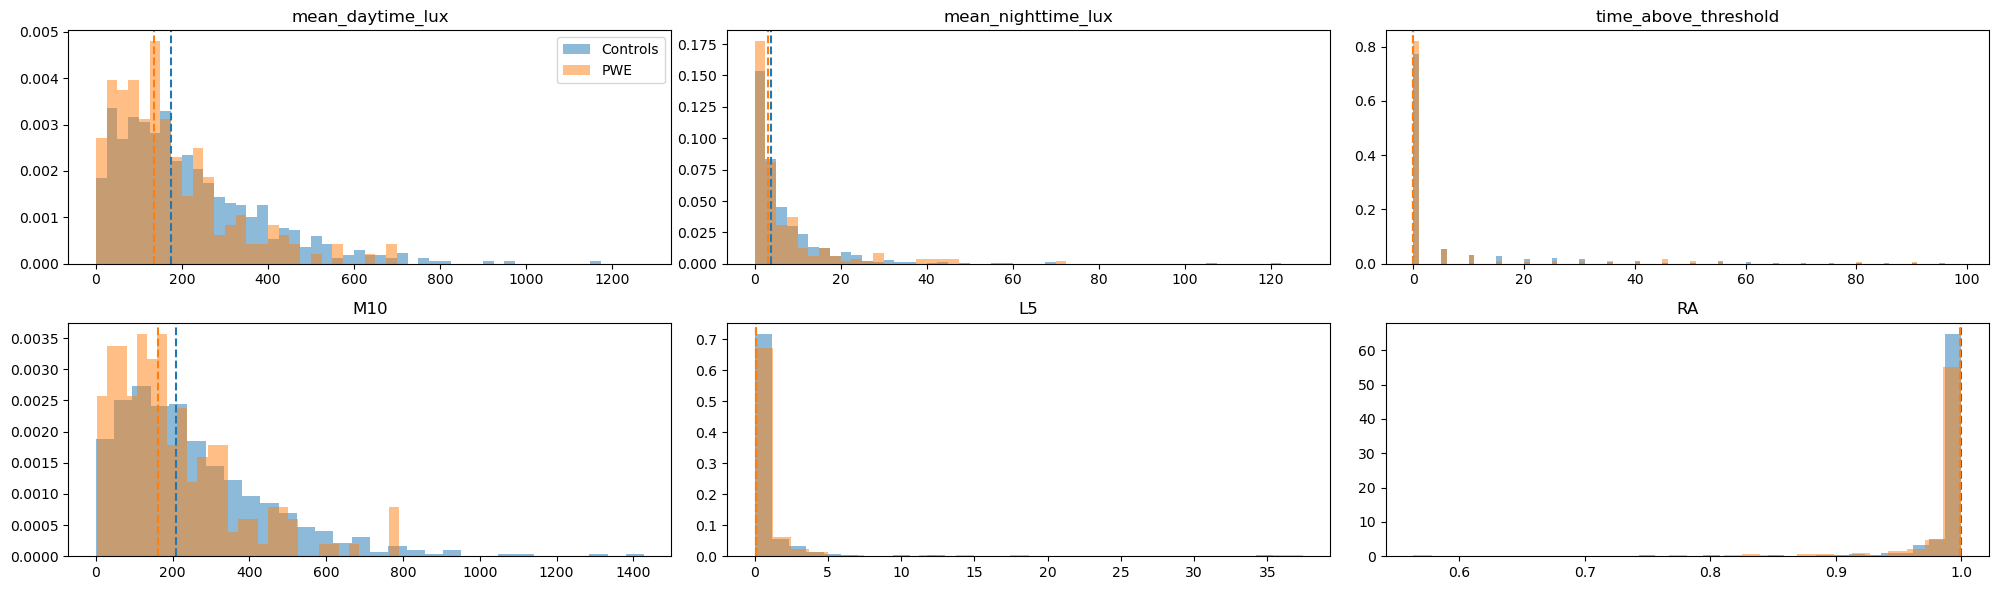

In [10]:
value_bins = {
    "mean_daytime_lux": np.arange(0, 1300, 25),
    "mean_nighttime_lux": np.arange(0, 130, 2.5),
    "time_above_threshold": np.arange(0, 100, 1),
    "M10": 30,
    "L5": 30,
    "RA": 30
}

fig, Ax = plt.subplots(2, 3, figsize=(20, 6), tight_layout=True)
Ax = Ax.reshape(-1)

for i, value in enumerate(value_bins.keys()):
    ax = Ax[i]
    ax.hist(df_control_summary[value], alpha=0.5, label="Controls", density=True, bins=value_bins[value])
    ax.hist(df_pwe_summary[value], alpha=0.5, label="PWE", density=True, bins=value_bins[value])
    ax.axvline(df_control_summary[value].median(), color='C0', ls='--')
    ax.axvline(df_pwe_summary[value].median(), color='C1', ls='--')
    ax.set_title(value)

    if i ==0:
        ax.legend()

plt.show()

There is a statistically relevent difference in mean daytime LUX between PWE and controls

                                 OLS Regression Results                                 
Dep. Variable:     np.log(mean_daytime_lux + 1)   R-squared:                       0.061
Model:                                      OLS   Adj. R-squared:                  0.053
Method:                           Least Squares   F-statistic:                     8.435
Date:                          Wed, 11 Mar 2026   Prob (F-statistic):           5.31e-10
Time:                                  10:17:48   Log-Likelihood:                -1202.3
No. Observations:                           861   AIC:                             2421.
Df Residuals:                               853   BIC:                             2459.
Df Model:                                     7                                         
Covariance Type:                            HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

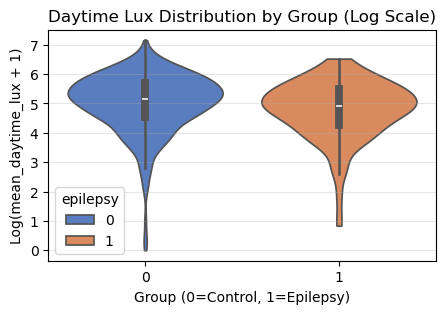

In [11]:
import statsmodels.formula.api as smf

model = smf.ols(
    "np.log(mean_daytime_lux + 1) ~ epilepsy + age + sex + PIR + a_ed + season + cohort",
    data=df_all
).fit(cov_type='HC3')

print(model.summary())


# Plot a violin plot
ax = plot_lux_distribution(df_all, x_col="epilepsy", y_col="mean_daytime_lux", use_log=True)

(<Figure size 300x300 with 1 Axes>,
 <Axes: title={'center': 'Adjusted Daytime Light Exposure'}, ylabel='Predicted log(mean daytime lux + 1)'>)

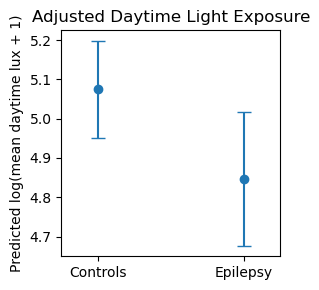

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_adjusted_epilepsy_effect(model, df):
    """
    Plot adjusted predicted daytime lux for controls vs epilepsy
    using a fitted statsmodels OLS model.

    Parameters
    ----------
    model : statsmodels regression results
        Fitted OLS model.
    df : pandas.DataFrame
        Dataframe used for fitting the model (to compute means of covariates).
    """

    # Build representative covariate values
    base = {
        "age": df["age"].mean(),
        "PIR": df["PIR"].mean(),
        "a_ed": df["a_ed"].mean(),
        "sex": df["sex"].mode()[0],
        "season": df["season"].mode()[0],
        "cohort": df["cohort"].mode()[0],
    }

    # Create prediction dataframe
    pred_df = pd.DataFrame([
        {**base, "epilepsy": 0},
        {**base, "epilepsy": 1}
    ])

    # Get predictions
    pred = model.get_prediction(pred_df)
    pred_summary = pred.summary_frame()

    means = pred_summary["mean"].values
    lower = pred_summary["mean_ci_lower"].values
    upper = pred_summary["mean_ci_upper"].values

    # Plot
    fig, ax = plt.subplots(figsize=(3, 3))

    x = [0, 1]

    ax.errorbar(
        x,
        means,
        yerr=[means - lower, upper - means],
        fmt="o",
        capsize=5
    )

    ax.set_xticks(x)
    ax.set_xticklabels(["Controls", "Epilepsy"])
    ax.set_xlim(-0.25, 1.25)

    ax.set_ylabel("Predicted log(mean daytime lux + 1)")
    ax.set_title("Adjusted Daytime Light Exposure")

    plt.tight_layout()

    return fig, ax


plot_adjusted_epilepsy_effect(model, df_all)

                                 OLS Regression Results                                 
Dep. Variable:     np.log(mean_daytime_lux + 1)   R-squared:                       0.065
Model:                                      OLS   Adj. R-squared:                  0.054
Method:                           Least Squares   F-statistic:                     6.155
Date:                          Wed, 11 Mar 2026   Prob (F-statistic):           2.12e-08
Time:                                  10:17:49   Log-Likelihood:                -1073.4
No. Observations:                           782   AIC:                             2167.
Df Residuals:                               772   BIC:                             2213.
Df Model:                                     9                                         
Covariance Type:                            HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

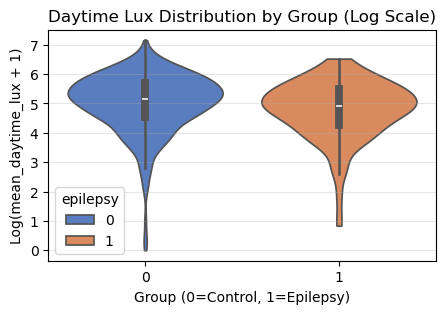

In [13]:
import statsmodels.formula.api as smf

model = smf.ols(
    "np.log(mean_daytime_lux + 1) ~ epilepsy + age + sex + PIR + a_ed + season + cohort + employed + depressed",
    data=df_all
).fit(cov_type='HC3')

print(model.summary())


# Plot a violin plot
ax = plot_lux_distribution(df_all, x_col="epilepsy", y_col="mean_daytime_lux", use_log=True)

In [41]:
df_all

,SEQN,timezone,duration_hours,mean_lux,mean_daytime_lux,mean_nighttime_lux,time_above_threshold,M10,L5,RA,cohort,epilepsy,employed,depressed
0,62218.0,UTC,222.166667,133.016037,242.679336,19.242723,0.0,283.219554,2.546784,0.982176,G,1,False,False
1,62282.0,UTC,192.083333,20.843251,40.438316,0.953299,0.0,46.339642,0.003403,0.999853,G,1,True,False
2,62293.0,UTC,192.083333,18.989081,36.077126,1.818291,0.0,42.688042,1.205729,0.945061,G,1,False,<NA>
3,62307.0,UTC,192.083333,44.976663,80.318809,4.919599,0.0,98.262948,1.641486,0.967139,G,1,False,False
4,62370.0,UTC,192.083333,62.269247,117.559670,1.761620,0.0,147.080298,0.000000,1.000000,G,1,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,81103.0,UTC,192.083333,122.073670,241.802721,0.923383,15.0,287.891632,0.397111,0.997245,H,0,False,False
857,81997.0,UTC,192.083333,184.755259,354.008004,10.198465,0.0,417.019819,0.200632,0.999038,H,0,False,False
858,78899.0,UTC,192.083333,49.309750,98.002270,0.595559,0.0,116.824593,0.000000,1.000000,H,0,False,False
859,76531.0,UTC,192.083333,20.822221,39.905744,1.034286,0.0,45.164121,0.245993,0.989166,H,0,False,False


## Stats

In [11]:
control = df_control_summary["mean_daytime_lux"].dropna()
pwe = df_pwe_summary["mean_daytime_lux"].dropna()


from scipy.stats import mannwhitneyu

u_stat, p_val = mannwhitneyu(control, pwe, alternative="two-sided")

print("=== Mann–Whitney U Test ===")
print("U statistic:", u_stat)
print("p-value:", p_val)


control_log = np.log(control + 1)
pwe_log = np.log(pwe + 1)

from scipy.stats import ttest_ind


t_stat_log, p_val_log = ttest_ind(control_log, pwe_log, equal_var=False)

print("=== Welch t-test on log(lux) ===")
print("t statistic:", t_stat_log)
print("p-value:", p_val_log)

=== Mann–Whitney U Test ===
U statistic: 13303.0
p-value: 0.015770463883092733
=== Welch t-test on log(lux) ===
t statistic: 2.0606683040682854
p-value: 0.04118992333587841


<Axes: >

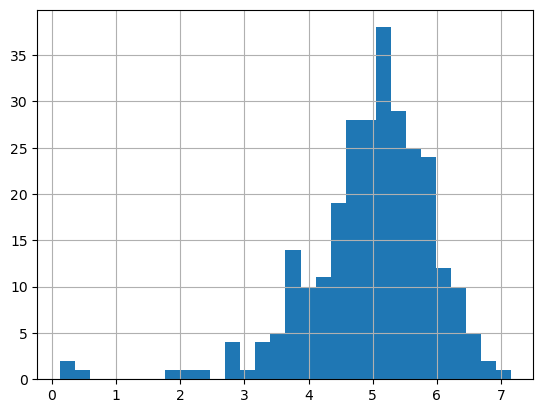

In [97]:
control_log.hist(bins=30)

<Axes: >

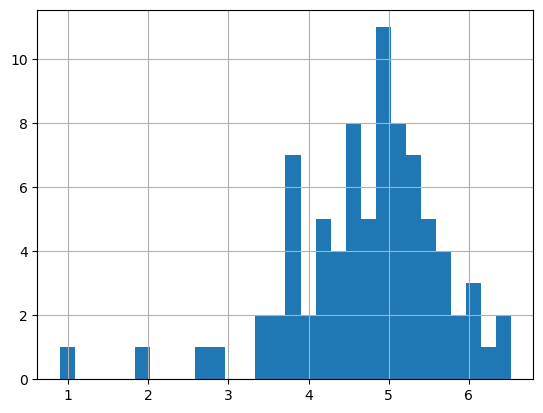

In [98]:
pwe_log.hist(bins=30)